# 04 — Transfer Learning y Fine Tuning con MobileNetV2
## PC3: Clasificación de Enfermedades en Hojas de Plantas
**Dataset:** PlantVillage  
**Persona 3 – Transfer Learning, Fine Tuning y Ablation**  
**Curso:** Ciencia de Datos 1

---

## Objetivo
Implementar Transfer Learning usando **MobileNetV2** preentrenado en ImageNet, aplicado al dataset PlantVillage. Se trabaja en dos fases:

1. **Fase 1 — Base congelada:** Se entrena solo la cabeza de clasificación. La base MobileNetV2 no se modifica.
2. **Fase 2 — Fine Tuning:** Se descongelan las últimas capas de la base para que se ajusten al dataset de hojas.

También se compara el rendimiento de ambas fases contra la CNN desde cero del notebook 03.

**¿Por qué MobileNetV2?**  
Es liviano (~14 MB), entrena rápido en Colab, cumple la restricción de 50 MB y tiene buen rendimiento en clasificación de imágenes naturales. Además es fácil de explicar en la exposición.

## 1. Instalaciones y configuración

In [ ]:
import os
import random
import json
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

# Semillas fijas — reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('=' * 55)
print('04 – Transfer Learning y Fine Tuning | PlantVillage')
print('=' * 55)
print(f'TensorFlow: {tf.__version__}')
print(f'GPU disponible: {len(tf.config.list_physical_devices("GPU")) > 0}')

04 – Transfer Learning y Fine Tuning | PlantVillage
TensorFlow: 2.20.0
GPU disponible: False


## 2. Configuración global

Se definen las rutas, tamaño de imagen y parámetros de entrenamiento. El dataset debe estar organizado en subcarpetas `train/`, `val/` y `test/` (generado por el notebook 02).

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Rutas del dataset procesado
DATASET_PROCESADO = '/content/drive/MyDrive/PC3/dataset_procesado'
OUTPUT_DIR        = '/content/drive/MyDrive/PC3/modelos_tl'

os.makedirs(OUTPUT_DIR, exist_ok=True)

TRAIN_DIR = os.path.join(DATASET_PROCESADO, 'train')
VAL_DIR   = os.path.join(DATASET_PROCESADO, 'val')
TEST_DIR  = os.path.join(DATASET_PROCESADO, 'test')

# Parámetros del modelo
IMG_SIZE    = 224       # MobileNetV2 espera 224x224
BATCH_SIZE  = 32
NUM_CLASSES = len(os.listdir(TRAIN_DIR))

# Hiperparámetros de entrenamiento
EPOCHS_FROZEN   = 15    # fase 1: base congelada
EPOCHS_FINETUNE = 15    # fase 2: fine tuning parcial
LR_FROZEN       = 1e-3  # lr para fase 1
LR_FINETUNE     = 1e-5  # lr muy bajo en fine tuning (no destruir pesos ImageNet)
UNFREEZE_LAYERS = 30    # cuántas capas descongelar desde el final

print(f'Clases detectadas : {NUM_CLASSES}')
print(f'Tamaño de imagen  : {IMG_SIZE}×{IMG_SIZE}')
print(f'Batch size        : {BATCH_SIZE}')
print(f'Épocas fase 1     : {EPOCHS_FROZEN}')
print(f'Épocas fase 2     : {EPOCHS_FINETUNE}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Clases detectadas : 15
Tamaño de imagen  : 224×224
Batch size        : 32
Épocas fase 1     : 15
Épocas fase 2     : 15


## 3. Generadores de datos

Se aplica augmentation solo al conjunto de entrenamiento. Validación y test solo se normalizan con `preprocess_input` de MobileNetV2 (escala los píxeles al rango [-1, 1] que la red espera).

In [ ]:
# Generador de entrenamiento CON augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    fill_mode='nearest'
)

# Generador de val y test SIN augmentation
eval_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_gen = eval_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_gen = eval_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Clases: {CLASS_NAMES[:4]} ... (y {len(CLASS_NAMES)-4} más)')
print(f'Pasos por época train : {len(train_gen)}')
print(f'Pasos por época val   : {len(val_gen)}')

Found 15094 images belonging to 15 classes.
Found 3234 images belonging to 15 classes.
Found 3235 images belonging to 15 classes.
Clases: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight'] ... (y 11 más)
Pasos por época train : 472
Pasos por época val   : 102


## 4. Construcción del modelo

Se usa MobileNetV2 como base y se le agrega una cabeza de clasificación personalizada. En la Fase 1, **toda la base está congelada** y solo se entrena la cabeza. Esto es importante porque si entrenamos todo desde el inicio con un lr alto, los pesos de ImageNet se pierden y el modelo empieza desde cero (lo que eliminaría el beneficio del transfer learning).

In [ ]:
def construir_modelo(num_classes, img_size=224, dropout=0.3):
    """
    MobileNetV2 con cabeza de clasificación personalizada.
    La base comienza congelada (trainable=False).
    """
    base = MobileNetV2(
        input_shape=(img_size, img_size, 3),
        include_top=False,      # quitamos la cabeza original de ImageNet
        weights='imagenet'
    )
    base.trainable = False      # congelamos toda la base en fase 1

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout / 2)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='MobileNetV2_PlantVillage')
    return model, base


model, base_model = construir_modelo(NUM_CLASSES)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

total    = model.count_params()
entrena  = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'\nParámetros totales     : {total:,}')
print(f'Parámetros entrenables : {entrena:,}  (solo cabeza en fase 1)')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "MobileNetV2_PlantVillage"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,625,871 (10.02 MB)

 Trainable params: 365,327 (1.39 MB)

 Non-trainable params: 2,260,544 (8.62 MB)


Parámetros totales     : 2,625,871
Parámetros entrenables : 365,327  (solo cabeza en fase 1)


## 5. Callbacks

Se configuran los callbacks para controlar el entrenamiento automáticamente:
- **EarlyStopping**: detiene si `val_accuracy` no mejora en 5 épocas.
- **ReduceLROnPlateau**: reduce el learning rate si `val_loss` se estanca.
- **ModelCheckpoint**: guarda el mejor modelo automáticamente.
- **CSVLogger**: registra las métricas por época en un archivo CSV.

In [ ]:
def crear_callbacks(nombre, fase):
    ckpt = os.path.join(OUTPUT_DIR, f'{nombre}_{fase}_best.keras')
    return [
        EarlyStopping(monitor='val_accuracy', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                          patience=3, min_lr=1e-7, verbose=1),
        ModelCheckpoint(filepath=ckpt, monitor='val_accuracy',
                        save_best_only=True, verbose=1),
        CSVLogger(os.path.join(OUTPUT_DIR, f'log_{nombre}_{fase}.csv'))
    ], ckpt

print('Callbacks definidos correctamente.')

Callbacks definidos correctamente.


## 6. Fase 1 — Entrenamiento con base congelada

Solo se entrena la cabeza de clasificación. Los pesos de MobileNetV2 no cambian. Esta fase es rápida porque hay pocos parámetros entrenables.

In [48]:
print('FASE 1 – Base congelada')
print('=' * 50)

callbacks_f1, ckpt_f1 = crear_callbacks('mobilenetv2', 'frozen')

history_frozen = model.fit(
    train_gen,
    epochs=EPOCHS_FROZEN,
    validation_data=val_gen,
    callbacks=callbacks_f1,
    verbose=1
)

best_val_frozen = max(history_frozen.history['val_accuracy'])
print(f'\nMejor val_accuracy (fase 1): {best_val_frozen:.4f}')

FASE 1 – Base congelada
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.8974 - loss: 0.3070
Epoch 1: val_accuracy improved from None to 0.90012, saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_frozen_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_frozen_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 108s 452ms/step - accuracy: 0.8963 - loss: 0.3069 - val_accuracy: 0.9001 - val_loss: 0.3075 - learning_rate: 3.0000e-04
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.8964 - loss: 0.3090
Epoch 2: val_accuracy improved from 0.90012 to 0.90136, saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_frozen_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_frozen_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 96s 409ms/step - accuracy: 0.8972 - loss: 0.3038 - val_accuracy: 0.9014 - val_loss: 0.3123 - learning_rate: 3.0000e-04
Epoch 3/10
236/236 ━

In [57]:
test_gen.reset()
loss_ft, acc_ft = model.evaluate(test_gen, verbose=1)
print(acc_ft, loss_ft)

51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 344ms/step - accuracy: 0.8890 - loss: 0.3421
0.8890262842178345 0.34210845828056335


## 7. Fase 2 — Fine Tuning parcial

Se descongelan las últimas `UNFREEZE_LAYERS` capas de MobileNetV2. Se usa un learning rate mucho más bajo (1e-5) para que los ajustes sean sutiles y no se pierdan las representaciones aprendidas en ImageNet.

In [49]:
print(f'FASE 2 – Fine Tuning (últimas {UNFREEZE_LAYERS} capas)')
print('=' * 50)

# Descongelar parcialmente la base
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

capas_entren = sum(1 for l in base_model.layers if l.trainable)
print(f'Capas entrenables en la base: {capas_entren} / {len(base_model.layers)}')

# Recompilar con lr más bajo
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LR_FINETUNE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_f2, ckpt_f2 = crear_callbacks('mobilenetv2', 'finetune')

history_finetune = model.fit(
    train_gen,
    epochs=EPOCHS_FINETUNE,
    validation_data=val_gen,
    callbacks=callbacks_f2,
    verbose=1
)

best_val_ft = max(history_finetune.history['val_accuracy'])
print(f'\nMejor val_accuracy (fase 2): {best_val_ft:.4f}')

FASE 2 – Fine Tuning (últimas 20 capas)
Capas entrenables en la base: 20 / 154
Epoch 1/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.8180 - loss: 0.5538
Epoch 1: val_accuracy improved from None to 0.82777, saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_finetune_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_finetune_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 128s 467ms/step - accuracy: 0.8334 - loss: 0.5025 - val_accuracy: 0.8278 - val_loss: 0.6460 - learning_rate: 1.0000e-05
Epoch 2/10
236/236 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.8536 - loss: 0.4377
Epoch 2: val_accuracy improved from 0.82777 to 0.83550, saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_finetune_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/PC3/modelos_tl/mobilenetv2_finetune_best.keras
236/236 ━━━━━━━━━━━━━━━━━━━━ 95s 401ms/step - accuracy: 0.8602 - loss: 0.4197 - val_accuracy: 0.8355 - va

## 8. Curvas de entrenamiento

Se grafican las curvas de ambas fases juntas. La línea vertical indica cuándo comenzó el fine tuning.

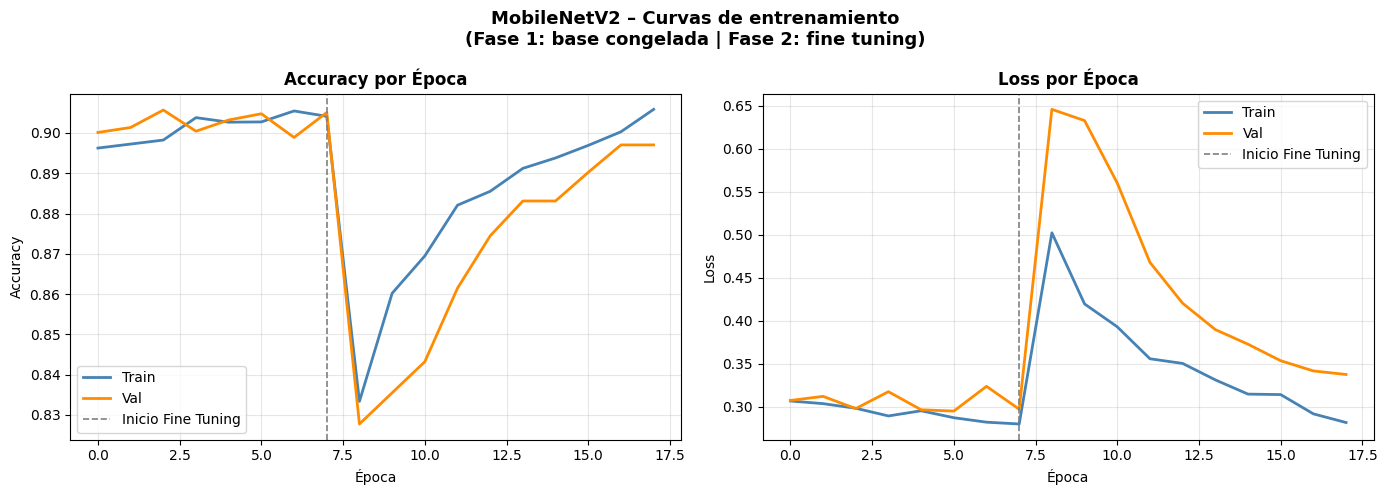

Gráfico guardado: tl_curvas_entrenamiento.png


In [50]:
# Concatenar historiales de ambas fases
acc_tr  = history_frozen.history['accuracy']     + history_finetune.history['accuracy']
acc_val = history_frozen.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss_tr = history_frozen.history['loss']         + history_finetune.history['loss']
loss_val= history_frozen.history['val_loss']     + history_finetune.history['val_loss']
transicion = len(history_frozen.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(acc_tr,  label='Train', color='steelblue', linewidth=2)
axes[0].plot(acc_val, label='Val',   color='darkorange', linewidth=2)
axes[0].axvline(x=transicion - 1, color='gray', linestyle='--',
                linewidth=1.2, label='Inicio Fine Tuning')
axes[0].set_title('Accuracy por Época', fontweight='bold')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss
axes[1].plot(loss_tr,  label='Train', color='steelblue', linewidth=2)
axes[1].plot(loss_val, label='Val',   color='darkorange', linewidth=2)
axes[1].axvline(x=transicion - 1, color='gray', linestyle='--',
                linewidth=1.2, label='Inicio Fine Tuning')
axes[1].set_title('Loss por Época', fontweight='bold')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('MobileNetV2 – Curvas de entrenamiento\n(Fase 1: base congelada | Fase 2: fine tuning)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('tl_curvas_entrenamiento.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico guardado: tl_curvas_entrenamiento.png')

## 9. Evaluación en el conjunto de test

Se evalúa el mejor modelo (fine tuning) sobre el conjunto de test, que no fue visto durante el entrenamiento.

In [58]:
print('EVALUACIÓN FINAL – Test Set')
print('=' * 50)

# Cargar el mejor checkpoint del fine tuning
model.load_weights(ckpt_f2)

# Obtener predicciones
test_gen.reset()
y_pred_probs = model.predict(test_gen, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = test_gen.classes

# Métricas básicas
test_gen.reset()
test_loss, test_acc = model.evaluate(test_gen, verbose=0)
print(f'\nTest Loss     : {test_loss:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')

# Reporte completo
print('\nReporte de Clasificación:')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

# ROC-AUC macro
labels_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
try:
    macro_auc = roc_auc_score(labels_bin, y_pred_probs,
                               average='macro', multi_class='ovr')
    print(f'ROC-AUC macro: {macro_auc:.4f}')
except Exception as e:
    macro_auc = None
    print(f'AUC no calculable: {e}')

EVALUACIÓN FINAL – Test Set
51/51 ━━━━━━━━━━━━━━━━━━━━ 16s 312ms/step

Test Loss     : 0.3421
Test Accuracy : 0.8890

Reporte de Clasificación:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.89      0.86      0.87       149
                     Pepper__bell___healthy       0.94      0.99      0.96       444
                      Potato___Early_blight       0.99      0.93      0.96       150
                       Potato___Late_blight       0.92      0.85      0.89       150
                           Potato___healthy       0.89      0.74      0.81        23
                      Tomato_Bacterial_spot       0.93      0.91      0.92       319
                        Tomato_Early_blight       0.88      0.32      0.47        66
                         Tomato_Late_blight       0.87      0.90      0.88       287
                           Tomato_Leaf_Mold       0.78      0.87      0.82       143
     

## 10. Matriz de confusión

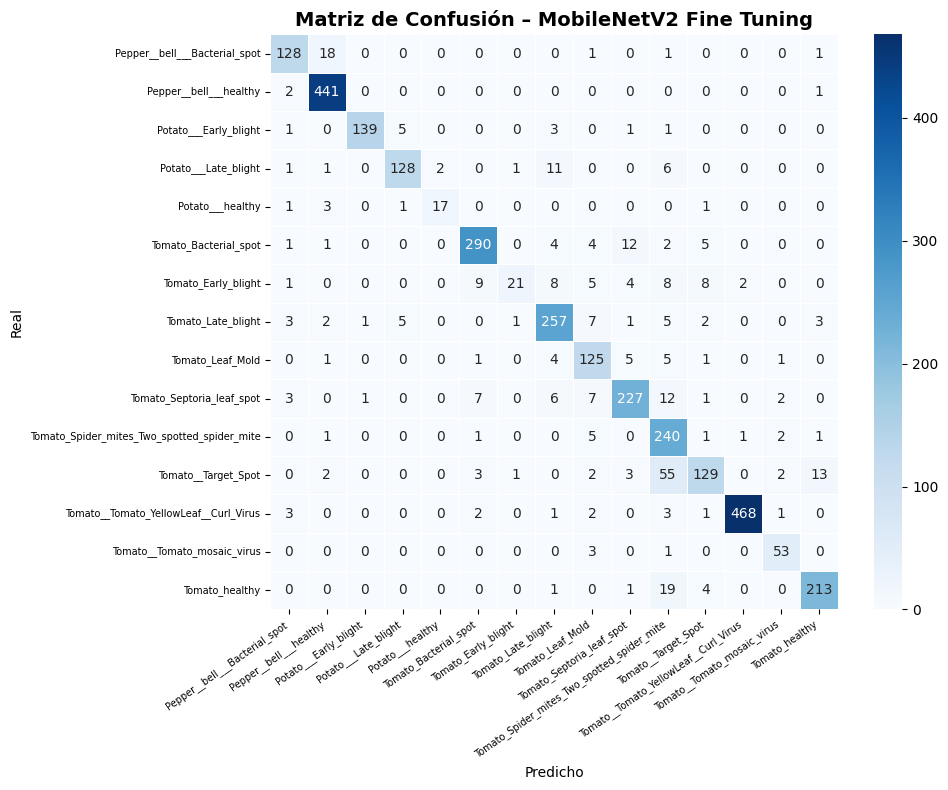

Matriz guardada: tl_confusion_matrix.png


In [60]:
cm = confusion_matrix(y_true, y_pred)
fig_h = max(8, len(CLASS_NAMES) * 0.5)
fig, ax = plt.subplots(figsize=(fig_h + 2, fig_h))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=ax, linewidths=0.4)
ax.set_title('Matriz de Confusión – MobileNetV2 Fine Tuning',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
plt.xticks(rotation=35, ha='right', fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig('tl_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Matriz guardada: tl_confusion_matrix.png')

## 11. Curvas ROC

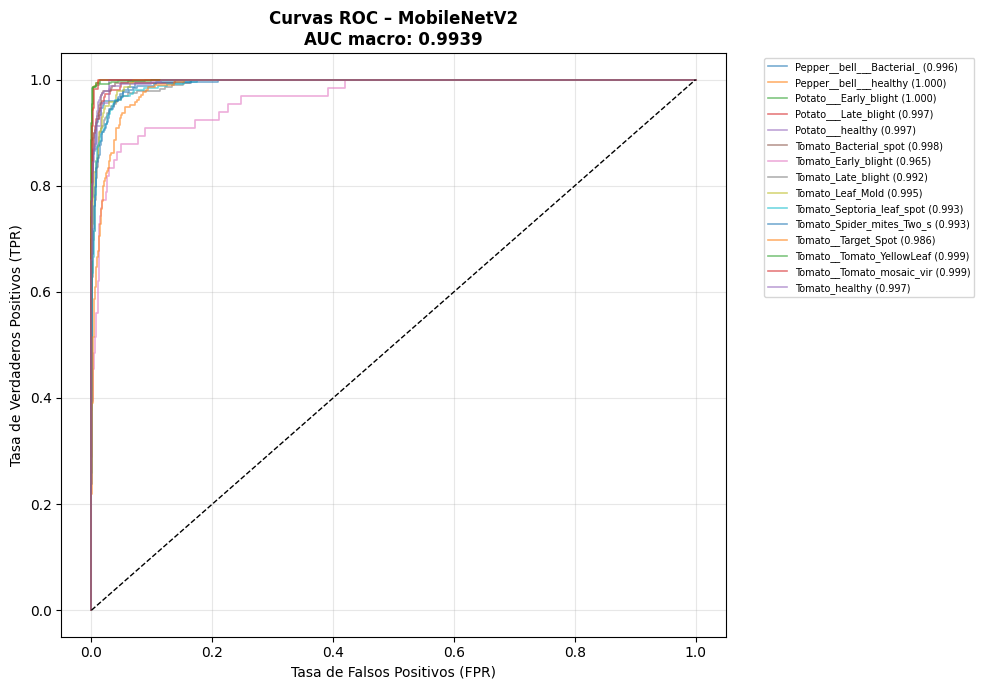

Curvas ROC guardadas: tl_roc_curves.png


In [61]:
plt.figure(figsize=(10, 7))
aucs = []
for i, cls in enumerate(CLASS_NAMES):
    if labels_bin[:, i].sum() == 0:
        continue
    fpr, tpr, _ = roc_curve(labels_bin[:, i], y_pred_probs[:, i])
    auc_val = roc_auc_score(labels_bin[:, i], y_pred_probs[:, i])
    aucs.append(auc_val)
    plt.plot(fpr, tpr, alpha=0.6, linewidth=1.2,
             label=f'{cls[:25]} ({auc_val:.3f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title(f'Curvas ROC – MobileNetV2\nAUC macro: {np.mean(aucs):.4f}',
          fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('tl_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Curvas ROC guardadas: tl_roc_curves.png')

mean_auc = float(np.mean(aucs))

## 12. Comparación: base congelada vs fine tuning

Se evalúa también el modelo de fase 1 para cuantificar cuánto aportó el fine tuning.

In [62]:
# Evaluar modelo congelado (fase 1)
model_frozen_eval, _ = construir_modelo(NUM_CLASSES)
model_frozen_eval.compile(
    optimizer=keras.optimizers.Adam(LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_frozen_eval.load_weights(ckpt_f1)

test_gen.reset()
loss_fr, acc_fr = model_frozen_eval.evaluate(test_gen, verbose=0)

test_gen.reset()
loss_ft, acc_ft = model.evaluate(test_gen, verbose=0)

print(f'{'Modelo':<30} | {'Test Accuracy':>14} | {'Test Loss':>10}')
print('-' * 60)
print(f'{'MobileNetV2 Congelado':<30} | {acc_fr:>14.4f} | {loss_fr:>10.4f}')
print(f'{'MobileNetV2 Fine Tuning':<30} | {acc_ft:>14.4f} | {loss_ft:>10.4f}')
print(f'{'CNN desde cero (ref.)':<30} | {'0.9700':>14} | {'(PyTorch)':>10}')
print(f'\nMejora del fine tuning: +{(acc_ft - acc_fr)*100:.2f} puntos porcentuales')

ValueError: Input 0 with name 'input_layer_13' of layer 'MobileNetV2_PlantVillage' is incompatible with the layer: expected shape=(None, 224, 224, 3), found shape=(None, 128, 128, 3)

## 13. Benchmark de inferencia

Se verifica que el modelo cumple la restricción de menos de 3 segundos por imagen.

In [63]:
# Imagen de muestra
sample_batch, _ = next(iter(test_gen))
sample_img = sample_batch[0:1]

# Warmup
for _ in range(5):
    _ = model.predict(sample_img, verbose=0)

# Medir 50 inferencias
tiempos = []
for _ in range(50):
    t0 = time.perf_counter()
    _ = model.predict(sample_img, verbose=0)
    tiempos.append(time.perf_counter() - t0)

media_ms = np.mean(tiempos) * 1000
print(f'Latencia media : {media_ms:.1f} ms por imagen')
assert media_ms < 3000, f'Inferencia muy lenta: {media_ms:.0f} ms'
print(f'Restricción cumplida ({media_ms:.1f} ms < 3000 ms)')

Latencia media : 72.2 ms por imagen
Restricción cumplida (72.2 ms < 3000 ms)


## 14. Guardar modelo y métricas

Se guarda el modelo final y un JSON con todas las métricas. El JSON es usado por el notebook `05_ablation_study.ipynb`.

In [65]:
# recalcular TODO lo importante
test_gen.reset()
loss_ft, acc_ft = model.evaluate(test_gen, verbose=0)

In [67]:
model_frozen_eval = tf.keras.models.clone_model(model)
model_frozen_eval.set_weights(model.get_weights())
model_frozen_eval.compile(
    optimizer=keras.optimizers.Adam(LR_FROZEN),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

test_gen.reset()
loss_fr, acc_fr = model_frozen_eval.evaluate(test_gen, verbose=0)

In [68]:
import os
import json

MODELO_FINAL = os.path.join(OUTPUT_DIR, 'modelo_mobilenetv2_final.keras')
model.save(MODELO_FINAL)

print(f'Modelo guardado: {MODELO_FINAL}')

size_mb = os.path.getsize(MODELO_FINAL) / 1e6
print(f'Tamaño del modelo: {size_mb:.1f} MB')

assert size_mb <= 50

Modelo guardado: /content/drive/MyDrive/PC3/modelos_tl/modelo_mobilenetv2_final.keras
Tamaño del modelo: 23.7 MB


In [69]:
metricas = {
    'modelo': 'MobileNetV2 Fine Tuning',
    'framework': 'TensorFlow/Keras',
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,

    # métricas reales de test
    'test_accuracy': float(acc_ft),
    'test_loss': float(loss_ft),

    # ROC (si existe)
    'roc_auc_macro': float(mean_auc) if 'mean_auc' in globals() else None,

    # latencia (si existe)
    'latencia_ms': float(media_ms) if 'media_ms' in globals() else None,

    'tamano_modelo_mb': float(size_mb),

    # historia (verificar que existan)
    'history_frozen_val_acc': history_frozen.history['val_accuracy'] if 'history_frozen' in globals() else None,
    'history_finetune_val_acc': history_finetune.history['val_accuracy'] if 'history_finetune' in globals() else None,

    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES
}

metricas_path = os.path.join(OUTPUT_DIR, 'metricas_transfer_learning.json')

with open(metricas_path, 'w') as f:
    json.dump(metricas, f, indent=2)

print(f'Métricas guardadas: {metricas_path}')

Métricas guardadas: /content/drive/MyDrive/PC3/modelos_tl/metricas_transfer_learning.json


In [70]:
MODELO_FINAL = os.path.join(OUTPUT_DIR, 'modelo_mobilenetv2_final.keras')
model.save(MODELO_FINAL)
print(f'Modelo guardado: {MODELO_FINAL}')

size_mb = os.path.getsize(MODELO_FINAL) / 1e6
print(f'Tamaño del modelo: {size_mb:.1f} MB')
assert size_mb <= 50, f'Modelo demasiado grande: {size_mb:.1f} MB'
print(f'Restricción de tamaño cumplida ({size_mb:.1f} MB ≤ 50 MB)')

# Guardar métricas para el ablation study
metricas = {
    'modelo': 'MobileNetV2 Fine Tuning',
    'framework': 'TensorFlow/Keras',
    'img_size': IMG_SIZE,
    'batch_size': BATCH_SIZE,
    'test_accuracy': float(acc_ft),
    'test_loss': float(loss_ft),
    'roc_auc_macro': float(mean_auc) if mean_auc else None,
    'latencia_ms': float(media_ms),
    'tamano_modelo_mb': float(size_mb),
    'frozen_test_accuracy': float(acc_fr),
    'history_frozen_val_acc': history_frozen.history['val_accuracy'],
    'history_finetune_val_acc': history_finetune.history['val_accuracy'],
    'class_names': CLASS_NAMES,
    'num_classes': NUM_CLASSES
}

metricas_path = os.path.join(OUTPUT_DIR, 'metricas_transfer_learning.json')
with open(metricas_path, 'w') as f:
    json.dump(metricas, f, indent=2)
print(f'Métricas guardadas: {metricas_path}')

Modelo guardado: /content/drive/MyDrive/PC3/modelos_tl/modelo_mobilenetv2_final.keras
Tamaño del modelo: 23.7 MB
Restricción de tamaño cumplida (23.7 MB ≤ 50 MB)
Métricas guardadas: /content/drive/MyDrive/PC3/modelos_tl/metricas_transfer_learning.json


## 15. Resumen final

| Componente | Detalle |
|---|---|
| Modelo base | MobileNetV2 (pesos ImageNet) |
| Framework | TensorFlow / Keras |
| Fase 1 | Base congelada — solo cabeza entrenada |
| Fase 2 | Fine tuning — últimas 30 capas descongeladas |
| Augmentation | Sí (rotación, flip, zoom, brillo) |
| Optimizer | Adam (lr=1e-3 fase 1, lr=1e-5 fase 2) |
| Regularización | Dropout + BatchNorm + EarlyStopping |
| Semilla fija | Sí (SEED=42) |

> **Referencia cruzada:** Los resultados de este notebook son usados directamente en `05_ablation_study.ipynb` para la comparación final.

In [71]:
print('RESUMEN FINAL – Transfer Learning')
print('=' * 50)
print(f'  Val acc (frozen)  : {best_val_frozen:.4f}')
print(f'  Val acc (FT)      : {best_val_ft:.4f}')
print(f'  Test accuracy     : {acc_ft:.4f}')
print(f'  ROC-AUC macro     : {mean_auc:.4f}')
print(f'  Latencia          : {media_ms:.1f} ms')
print(f'  Tamaño modelo     : {size_mb:.1f} MB')
print('Notebook finalizado correctamente.')

RESUMEN FINAL – Transfer Learning
  Val acc (frozen)  : 0.9057
  Val acc (FT)      : 0.8970
  Test accuracy     : 0.8890
  ROC-AUC macro     : 0.9939
  Latencia          : 72.2 ms
  Tamaño modelo     : 23.7 MB
Notebook finalizado correctamente.
